In [1]:

# Predict whether a student will pass or fail based on features.

objective = "Classification: Pass (Yes/No)"
success_criteria = "Accuracy > 85%"
constraints = "Limited data, missing values, class imbalance"

print("Objective:", objective)
print("Success Criteria:", success_criteria)
print("Constraints:", constraints)


Objective: Classification: Pass (Yes/No)
Success Criteria: Accuracy > 85%
Constraints: Limited data, missing values, class imbalance


In [ ]:

# Step2 Data Collection
import pandas as pd                 # Load dataset (Titanic dataset from seaborn or CSV)
import seaborn as sns
df = sns.load_dataset("titanic")
print("Data shape:", df.shape)
print(df.head())

Data shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [2]:
import pandas as pd
import seaborn as sns

# Load Titanic dataset
df = sns.load_dataset("titanic")

# Step 3: Data Cleaning & Preprocessing

# Drop unnecessary columns
df = df.drop(columns=['deck', 'who', 'embark_town', 'alive'], errors='ignore')

# Handle missing values
df['age'] = df['age'].fillna(df['age'].median())

if 'embarked' in df.columns:
    df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop duplicate rows
df = df.drop_duplicates()

# Encode categorical variables
columns_to_encode = ['sex', 'class']

if 'embarked' in df.columns:
    columns_to_encode.append('embarked')

df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)

# Feature Engineering: Family Size
df['family_size'] = df['sibsp'] + df['parch']

print(df.head())

   survived  pclass   age  sibsp  parch     fare  adult_male  alone  sex_male  \
0         0       3  22.0      1      0   7.2500        True  False      True   
1         1       1  38.0      1      0  71.2833       False  False     False   
2         1       3  26.0      0      0   7.9250       False   True     False   
3         1       1  35.0      1      0  53.1000       False  False     False   
4         0       3  35.0      0      0   8.0500        True   True      True   

   class_Second  class_Third  embarked_Q  embarked_S  family_size  
0         False         True       False        True            1  
1         False        False       False       False            1  
2         False         True       False        True            0  
3         False        False       False        True            1  
4         False         True       False        True            0  


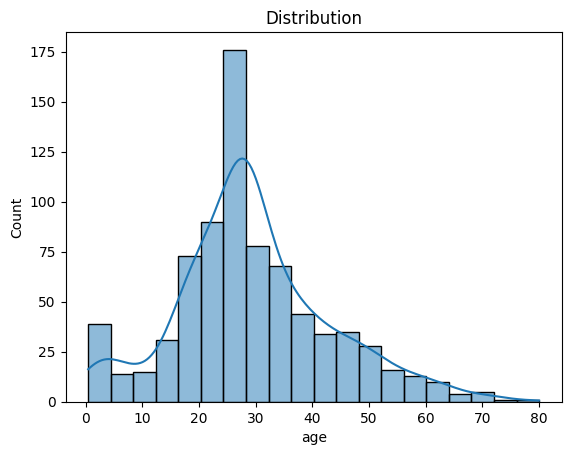

In [ ]:


# Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of age
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Distribution")
plt.show()



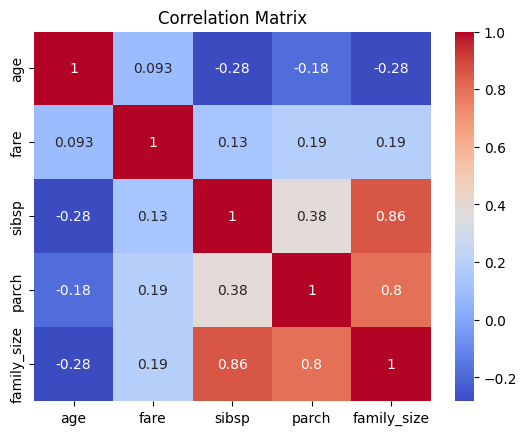

In [ ]:
# Correlation Matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Select specific numeric columns
corr = df[['age', 'fare', 'sibsp', 'parch', 'family_size']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Step 5: Data Modeling

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Define selected features and target
X = df[['age', 'fare', 'family_size']]
y = df['survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#  Model Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.6838709677419355
Precision: 0.6896551724137931
Recall: 0.3333333333333333
Confusion Matrix:
 [[86  9]
 [40 20]]
